# Records Matching

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
mention_file = "./data/all_mentions.csv"
assertion_file = "./data/all_assertions.csv"
MENTION = pd.read_csv(mention_file, low_memory=False).set_index('mention_id')
ASSERTION = pd.read_csv(assertion_file, low_memory=False).set_index('assertion_id')
# MENTION_SOURCE = MENTION.groupby('source')
# ASSERTION_PREDICATE = ASSERTION.groupby('predicate')

In [18]:
MENTION.head()

,source,source_year,county,original_data,confidence,full_name,first_name,middle_name,last_name,maiden_name,...,nysiis_last_name,norm_race,norm_occupation,enslaver_id,location_id,head,household_id,family_id,created,narrative
mention_id,,,,,,,,,,,,,,,,,,,,,
a632802a-a920-4a60-b231-504c103e1bbe,ALB_SS-1860,1860,ALB,"{""age"": ""36"", ""line"": ""5685"", ""race"": ""B"", ""ge...",0.82,NaN,NaN,NaN,NaN,NaN,...,NaN,B,NaN,NaN,NaN,f,NaN,NaN,2026-05-15 15:54:26.722785+00,NaN
e4cf1dc7-dc28-478f-989c-8d1be7c0f33b,ALB_SS-1860,1860,ALB,"{""age"": ""34"", ""line"": ""5686"", ""race"": ""B"", ""ge...",0.82,NaN,NaN,NaN,NaN,NaN,...,NaN,B,NaN,NaN,NaN,f,NaN,NaN,2026-05-15 15:54:26.722785+00,NaN
e0153e40-ebba-4de8-bd4c-9cb8298668bd,ALB_SS-1860,1860,ALB,"{""age"": ""52"", ""line"": ""5687"", ""race"": ""M"", ""ge...",0.82,NaN,NaN,NaN,NaN,NaN,...,NaN,B,NaN,NaN,NaN,f,NaN,NaN,2026-05-15 15:54:26.722785+00,NaN
d7fd0920-495a-45af-82b6-cf77b4605d92,ALB_SS-1860,1860,ALB,"{""age"": ""53"", ""line"": ""5688"", ""race"": ""B"", ""ge...",0.82,NaN,NaN,NaN,NaN,NaN,...,NaN,B,NaN,NaN,NaN,f,NaN,NaN,2026-05-15 15:54:26.722785+00,NaN
e9c5aec0-c140-4f08-9a86-caf8d4e9d734,ALB_SS-1860,1860,ALB,"{""age"": ""48"", ""line"": ""5689"", ""race"": ""M"", ""ge...",0.82,NaN,NaN,NaN,NaN,NaN,...,NaN,B,NaN,NaN,NaN,f,NaN,NaN,2026-05-15 15:54:26.722785+00,NaN


In [23]:
print("Duplicate indexes?", MENTION.index.has_duplicates)
print("Duplicate data?", MENTION.shape[0] > MENTION.drop_duplicates().shape[0])

Duplicate indexes? False
Duplicate data? False


In [27]:
MENTION.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114736 entries, a632802a-a920-4a60-b231-504c103e1bbe to b6f58112-33f3-4f64-aae6-048d49ce3c97
Data columns (total 28 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   source            114736 non-null  category
 1   source_year       114736 non-null  int64   
 2   county            114736 non-null  category
 3   original_data     114736 non-null  object  
 4   confidence        114736 non-null  float64 
 5   full_name         86492 non-null   object  
 6   first_name        84829 non-null   object  
 7   middle_name       24375 non-null   object  
 8   last_name         85297 non-null   object  
 9   maiden_name       0 non-null       float64 
 10  birth_year        96201 non-null   float64 
 11  death_year        1611 non-null    float64 
 12  race              114736 non-null  category
 13  gender            114736 non-null  category
 14  occupation        114736 non-null  categ

In [9]:
MENTION.value_counts('source')

source
ALB_CN_1880       35406
ALB_VR_1715       23473
ALB_CN_1870       22587
ALB_SS-1860       15697
ALB_SS-1850       14081
ALB_FindAGrave     1611
ALB_FBR            1193
ALB_FL-1865         688
Name: count, dtype: int64

In [20]:
ASSERTION.head()

,subject_id,predicate,object_id,object_string,start_year,end_year,who,confidence,created,county
assertion_id,,,,,,,,,,
bb358496-2b77-4c22-b95d-bb21aad0e70f,354884aa-76f6-4bee-87b4-fa4c3e459ad7,isSiblingOf,db93ea35-d868-42bd-aadd-c58d9c7c3303,NaN,1880,NaN,expanded,0.9,2026-05-15 15:58:37.826071+00,ALB
fc5b8f22-0916-47e2-82ec-599634b5165f,126439b9-4304-4428-8071-7bb60929b572,isSiblingOf,594ea5c6-e25e-478f-8581-27b7a3f09477,NaN,1870,NaN,1870Census,0.5,2026-05-15 15:32:40.755776+00,ALB
cc0233a4-97b7-42be-8e52-5856124c7ad9,594ea5c6-e25e-478f-8581-27b7a3f09477,isSiblingOf,73f2a8d2-4184-4bf0-bc60-68ebf491927a,NaN,1870,NaN,1870Census,0.5,2026-05-15 15:32:40.755776+00,ALB
52a6c078-1355-40b6-95cc-b4d3ff6f17c9,73f2a8d2-4184-4bf0-bc60-68ebf491927a,isSiblingOf,ee73bc4b-4f5f-4d1f-8683-a76b0ce3bf8d,NaN,1870,NaN,1870Census,0.5,2026-05-15 15:32:40.755776+00,ALB
1a7aa6a5-bcfe-4836-94b4-85952722b8a3,ee73bc4b-4f5f-4d1f-8683-a76b0ce3bf8d,isSpouseOf,49d22c94-b8be-455b-9b70-f8f1fdfd393d,NaN,1870,NaN,1870Census,0.5,2026-05-15 15:32:40.755776+00,ALB


In [28]:
ASSERTION.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64209 entries, bb358496-2b77-4c22-b95d-bb21aad0e70f to 8cee3bda-46e0-4f76-a44f-2b9cea7997f4
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject_id     64209 non-null  object 
 1   predicate      64209 non-null  object 
 2   object_id      64209 non-null  object 
 3   object_string  0 non-null      float64
 4   start_year     64209 non-null  int64  
 5   end_year       8251 non-null   float64
 6   who            64209 non-null  object 
 7   confidence     64209 non-null  float64
 8   created        64209 non-null  object 
 9   county         64209 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 5.4+ MB


In [14]:
ASSERTION.value_counts('predicate')

predicate
isSiblingOf         18067
isChildOf           12604
isParentOf          12604
wasEnslavedBy        8251
isSpouseOf           4520
IsMotherOf           2222
isGrandChildOf       1890
isGrandParentOf      1890
IsFatherOf           1564
isNiblingOf           179
isPiblingOf           179
isSiblingInLawOf       84
isParentInLawOf        63
isChildInLawOf         57
isCousinOf             25
isGrandmotherOf         9
isGrandfatherOf         1
Name: count, dtype: int64

## Import and Transform Mentions Data

The data required some regex massaging from the SQL prior to importing.

In [ ]:
## Select cols for linkage
col_link = ['full_name', 'birth_year', 'norm_race', 'gender', 'norm_occupation', 'legal_status', 'head', 'enslaver_id']

M = MENTION[col_link].set_index(ohco).sort_index().copy()

print(len(M))
M.sample(10)

114736


,,,,,norm_occupation,head,enslaver_id
birth_year,legal_status,norm_race,gender,full_name,,,
NaN,_,_,M,Jordan Tiller,_,NaN,NaN
1868.0,F,W,M,Wm R Walters,_,f,NaN
1879.0,F,W,F,Dudley,_,f,NaN
1856.0,F,W,M,Frank H Thurman,EDUCATION,f,NaN
NaN,_,_,_,James B Turner,_,f,NaN
1850.0,E,B,M,NaN,_,f,NaN
NaN,_,_,M,Nathaniel Johnson E Johnson,_,NaN,NaN
1853.0,E,B,F,NaN,_,f,NaN
1830.0,E,B,F,NaN,_,f,NaN


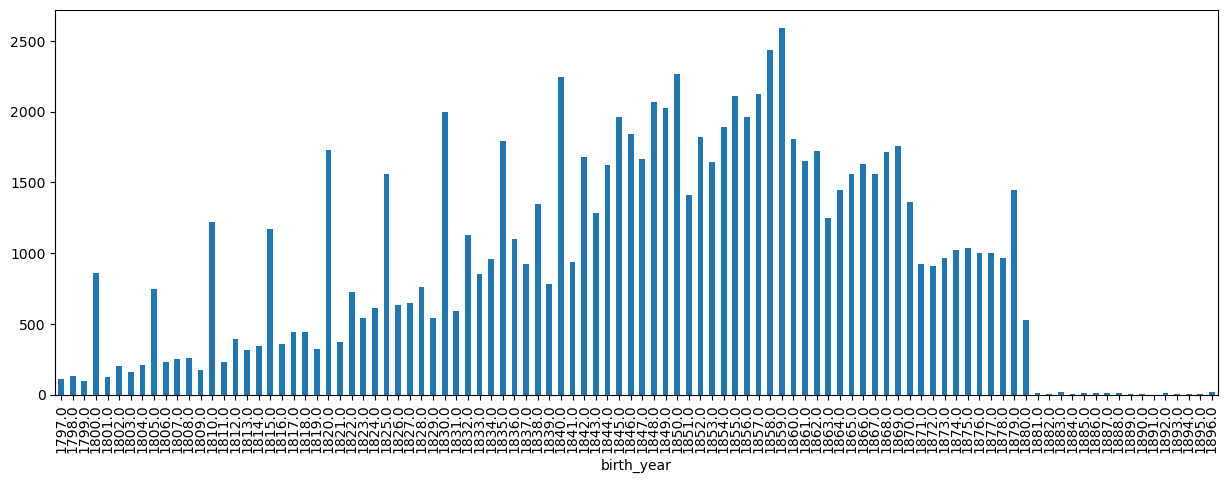

In [36]:
X = MENTION.value_counts('birth_year').sort_index().tail(100).plot.bar(figsize=(15,5))

In [37]:
BLACK = M.value_counts(['birth_year','norm_race','gender','full_name'])\
    .to_frame('n_recs')\
    .query("n_recs > 0 & full_name != '' & birth_year >= 1800 & norm_race == 'B'")\
    .sort_index()
BLACK.sample(10)

,,,,n_recs
birth_year,norm_race,gender,full_name,
1864.0,B,M,Daniel Sillers,1
1849.0,B,F,Leunna Roberson,1
1867.0,B,F,May Carter,1
1833.0,B,M,Wm Campbell,1
1874.0,B,M,Samuel Payne,1
1853.0,B,M,Scott Childress,1
1810.0,B,F,Lucy Webster,1
1846.0,B,M,William Jones,1
1825.0,B,M,Richard Carr,1


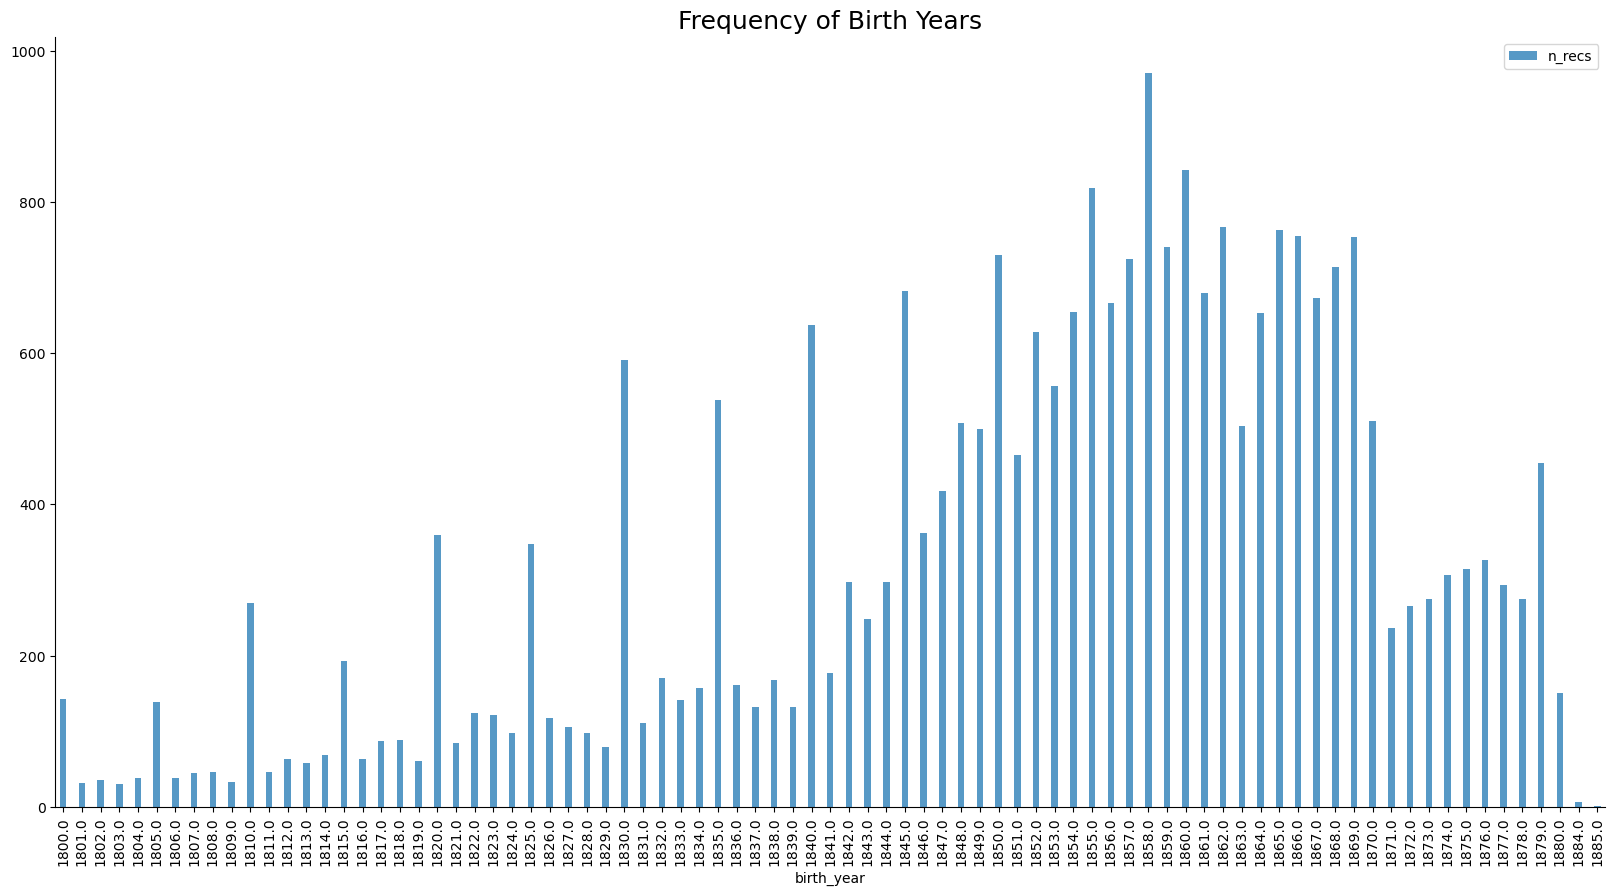

In [38]:
BLACK.groupby('birth_year', observed=True).count().plot.bar(width=.35, alpha=.75, figsize=(20,10))
sns.despine()
plt.title("Frequency of Birth Years", fontsize=18)
plt.show()

## Save

In [41]:
MENTION.to_parquet("MENTION.parquet", index=True)
ASSERTION.to_parquet("ASSERTION.parquet", index=True)
M.to_parquet("M.parquet", index=True)